In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import torch
import torch.nn as nn
import math

__all__ = ['effnetv2_s', 'effnetv2_m', 'effnetv2_l', 'effnetv2_xl']


def _make_divisible(v, divisor, min_value=None):
    """
    This function is taken from the original tf repo.
    It ensures that all layers have a channel number that is divisible by 8
    It can be seen here:
    https://github.com/tensorflow/models/blob/master/research/slim/nets/mobilenet/mobilenet.py
    :param v:
    :param divisor:
    :param min_value:
    :return:
    """
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    # Make sure that round down does not go down by more than 10%.
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


# SiLU (Swish) activation function
if hasattr(nn, 'SiLU'):
    SiLU = nn.SiLU
else:
    # For compatibility with old PyTorch versions
    class SiLU(nn.Module):
        def forward(self, x):
            return x * torch.sigmoid(x)

 
class SELayer(nn.Module):
    def __init__(self, inp, oup, reduction=4):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
                nn.Linear(oup, _make_divisible(inp // reduction, 8)),
                SiLU(),
                nn.Linear(_make_divisible(inp // reduction, 8), oup),
                nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        SiLU()
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        SiLU()
    )


class MBConv(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio, use_se):
        super(MBConv, self).__init__()
        assert stride in [1, 2]

        hidden_dim = round(inp * expand_ratio)
        self.identity = stride == 1 and inp == oup
        if use_se:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                SiLU(),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                SiLU(),
                SELayer(inp, hidden_dim),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # fused
                nn.Conv2d(inp, hidden_dim, 3, stride, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                SiLU(),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )


    def forward(self, x):
        if self.identity:
            return x + self.conv(x)
        else:
            return self.conv(x)


class EffNetV2(nn.Module):
    def __init__(self, cfgs, num_classes=1000, width_mult=1.):
        super(EffNetV2, self).__init__()
        self.cfgs = cfgs

        # building first layer
        input_channel = _make_divisible(24 * width_mult, 8)
        layers = [conv_3x3_bn(3, input_channel, 2)]
        # building inverted residual blocks
        block = MBConv
        for t, c, n, s, use_se in self.cfgs:
            output_channel = _make_divisible(c * width_mult, 8)
            for i in range(n):
                layers.append(block(input_channel, output_channel, s if i == 0 else 1, t, use_se))
                input_channel = output_channel
        self.features = nn.Sequential(*layers)
        # building last several layers
        output_channel = _make_divisible(1792 * width_mult, 8) if width_mult > 1.0 else 1792
        self.conv = conv_1x1_bn(input_channel, output_channel)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(output_channel, num_classes)

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.conv(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.001)
                m.bias.data.zero_()


def effnetv2_s(**kwargs):
    """
    Constructs a EfficientNetV2-S model
    """
    cfgs = [
        # t, c, n, s, SE
        [1,  12,  2, 1, 0],
        [1,  24,  2, 1, 0],
        [4,  48,  4, 2, 0],
        [4,  64,  4, 2, 0],
        [4, 128,  6, 2, 1],
        [6, 160,  9, 1, 1],
        [6, 256, 15, 2, 1],
    ]
    return EffNetV2(cfgs, **kwargs)


def effnetv2_m(**kwargs):
    """
    Constructs a EfficientNetV2-M model
    """
    cfgs = [
        # t, c, n, s, SE
        [1,  24,  3, 1, 0],
        [4,  48,  5, 2, 0],
        [4,  80,  5, 2, 0],
        [4, 160,  7, 2, 1],
        [6, 176, 14, 1, 1],
        [6, 304, 18, 2, 1],
        [6, 512,  5, 1, 1],
    ]
    return EffNetV2(cfgs, **kwargs)


def effnetv2_l(**kwargs):
    """
    Constructs a EfficientNetV2-L model
    """
    cfgs = [
        # t, c, n, s, SE
        [1,  32,  4, 1, 0],
        [4,  64,  7, 2, 0],
        [4,  96,  7, 2, 0],
        [4, 192, 10, 2, 1],
        [6, 224, 19, 1, 1],
        [6, 384, 25, 2, 1],
        [6, 640,  7, 1, 1],
    ]
    return EffNetV2(cfgs, **kwargs)


def effnetv2_xl(**kwargs):
    """
    Constructs a EfficientNetV2-XL model
    """
    cfgs = [
        # t, c, n, s, SE
        [1,  32,  4, 1, 0],
        [4,  64,  8, 2, 0],
        [4,  96,  8, 2, 0],
        [4, 192, 16, 2, 1],
        [6, 256, 24, 1, 1],
        [6, 512, 32, 2, 1],
        [6, 640,  8, 1, 1],
    ]
    return EffNetV2(cfgs, **kwargs)

In [3]:
from torchvision import datasets

train_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    download=True
)

val_dataset = datasets.Flowers102(
    root="./data",
    split="val",
    download=True
)

test_dataset = datasets.Flowers102(
    root="./data",
    split="test",
    download=True
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1020
1020
6149


In [4]:
image, label = train_dataset[0]

print(image)
print("Label:", label)

<PIL.Image.Image image mode=RGB size=754x500 at 0x155550449730>
Label: 0


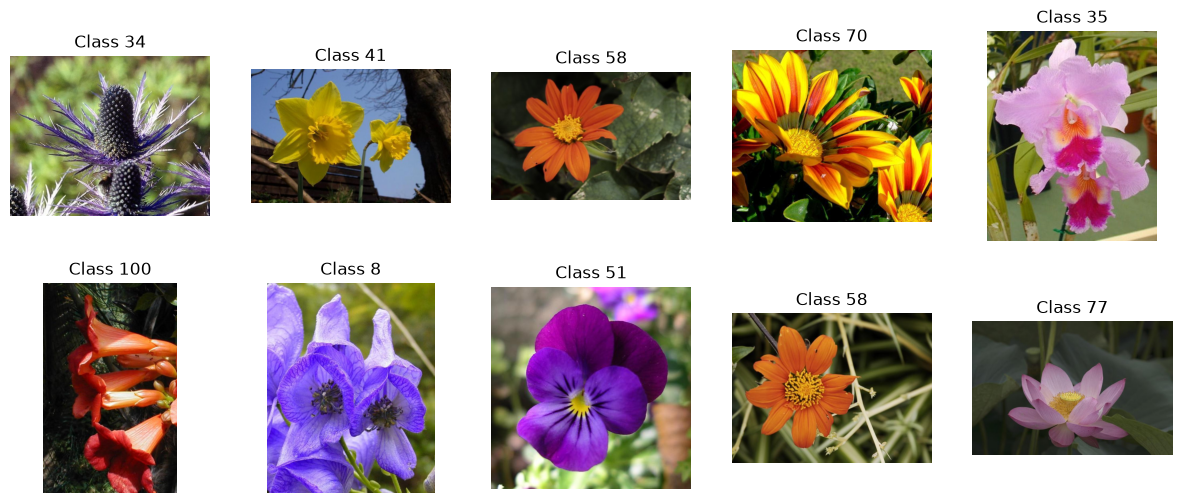

In [5]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax in axes.flat:
    idx = np.random.randint(len(train_dataset))
    image, label = train_dataset[idx]

    ax.imshow(image)
    ax.set_title(f"Class {label}")
    ax.axis("off")

plt.show()

In [6]:
IMG_SIZE = 224

In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
train_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    transform=train_transform,
    download=True
)

val_dataset = datasets.Flowers102(
    root="./data",
    split="val",
    transform=test_transform,
    download=True
)

test_dataset = datasets.Flowers102(
    root="./data",
    split="test",
    transform=test_transform,
    download=True
)

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [10]:
import torch
import torch.nn as nn

model = effnetv2_s(num_classes=102)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

cuda


In [11]:
num_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Parameters: {num_params:,}")

Parameters: 20,498,902


In [12]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)

Input: torch.Size([16, 3, 224, 224])
Output: torch.Size([16, 102])


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [14]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [16]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [17]:
import time
NUM_EPOCHS = 2

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0

# Record the starting time
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "effnetv2_s_flowers102_best.pth"
        )
# Record the ending time
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training with 2 epochs took {elapsed_time:.2f} seconds to complete.")

Epoch 01/2 | Train Loss: 4.6888 | Train Acc: 0.0118 | Val Loss: 4.5985 | Val Acc: 0.0088
Epoch 02/2 | Train Loss: 4.4145 | Train Acc: 0.0167 | Val Loss: 4.5920 | Val Acc: 0.0235
Training with 2 epochs took 26.81 seconds to complete.


In [18]:
model.load_state_dict(
    torch.load(
        "effnetv2_s_flowers102_best.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [19]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 4.7281
Test Accuracy: 0.0408


In [20]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             384
       BatchNorm2d-8         [-1, 16, 112, 112]              32
            MBConv-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 16, 112, 112]           2,304
      BatchNorm2d-11         [-1, 16, 112, 112]              32
             SiLU-12         [-1, 16, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             256
      BatchNorm2d-14         [-1, 16, 1

In [21]:
print('========================================')

In [22]:
import scipy.io

In [23]:
correct_images = []
incorrect_images = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        for i in range(len(images)):

            if predictions[i] == labels[i]:

                correct_images.append({
                    "image": images[i].cpu(),
                    "label": labels[i].item(),
                    "prediction": predictions[i].item()
                })

            else:

                incorrect_images.append({
                    "image": images[i].cpu(),
                    "label": labels[i].item(),
                    "prediction": predictions[i].item()
                })

            if len(correct_images) >= 2 and len(incorrect_images) >= 2:
                break

        if len(correct_images) >= 2 and len(incorrect_images) >= 2:
            break

In [30]:
print("Correct:", len(correct_images))
print("Incorrect:", len(incorrect_images))

Correct: 2
Incorrect: 484


AttributeError: 'list' object has no attribute 'type'

In [25]:
import numpy as np

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize(image):

    image = image * std + mean

    image = torch.clamp(image, 0, 1)

    return image

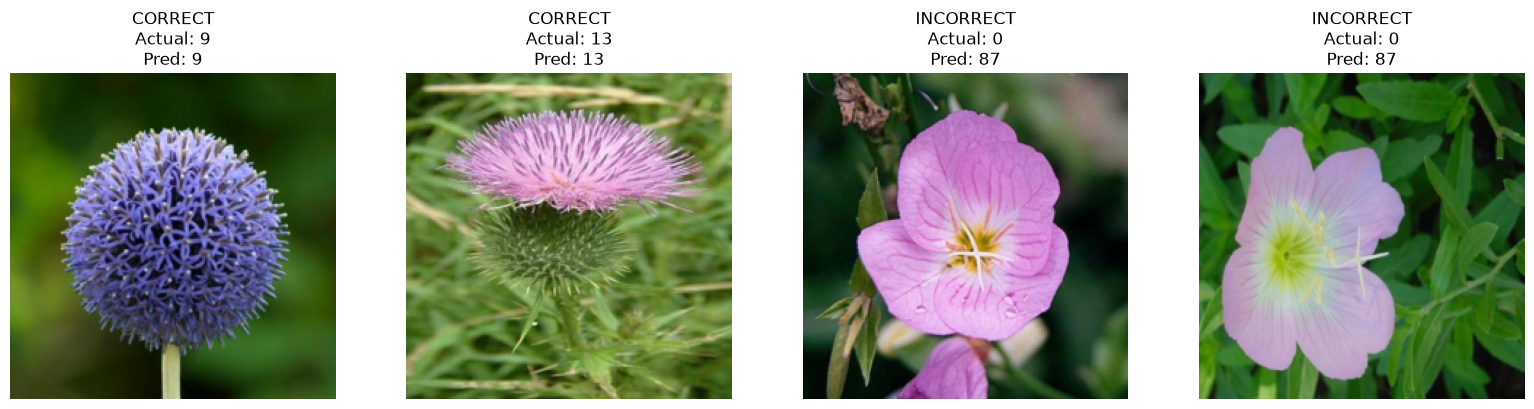

In [31]:
import matplotlib.pyplot as plt

examples = correct_images + incorrect_images

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4)
)

for ax, example in zip(axes, examples):

    image = denormalize(example["image"])
    image = image.permute(1, 2, 0)

    ax.imshow(image)

    if example["label"] == example["prediction"]:
        result = "CORRECT"
    else:
        result = "INCORRECT"

    ax.set_title(
        f"{result}\n"
        f"Actual: {example['label']}\n"
        f"Pred: {example['prediction']}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
print(model.features)

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
  )
  (1): MBConv(
    (conv): Sequential(
      (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(24, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (2): MBConv(
    (conv): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (4)

In [33]:
target_layer = model.features[-1]

In [34]:
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):

        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):

        self.gradients = grad_output[0]

    def generate(self, image, class_idx=None):

        self.model.zero_grad()

        output = self.model(image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]

        score.backward()

        activations = self.activations
        gradients = self.gradients

        # Average gradients over spatial dimensions
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted sum of feature maps
        cam = (weights * activations).sum(dim=1)

        # ReLU
        cam = torch.relu(cam)

        # Normalize to [0, 1]
        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return cam.detach().cpu().numpy()[0]

In [35]:
target_layer = model.features[-1]

gradcam = GradCAM(
    model,
    target_layer
)

In [36]:
example = correct_images[0]

image = example["image"].unsqueeze(0).to(device)

In [37]:
cam = gradcam.generate(image)

In [38]:
print(cam.shape)

(7, 7)


In [43]:
pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 105.4 MB/s  0:00:00m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [44]:
import cv2

heatmap = cv2.resize(
    cam,
    (224, 224)
)

In [45]:
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

heatmap = heatmap.astype(np.float32) / 255

In [46]:
original = denormalize(
    example["image"]
)

original = original.permute(
    1, 2, 0
).numpy()

In [47]:
overlay = 0.5 * original + 0.5 * heatmap

overlay = np.clip(
    overlay,
    0,
    1
)

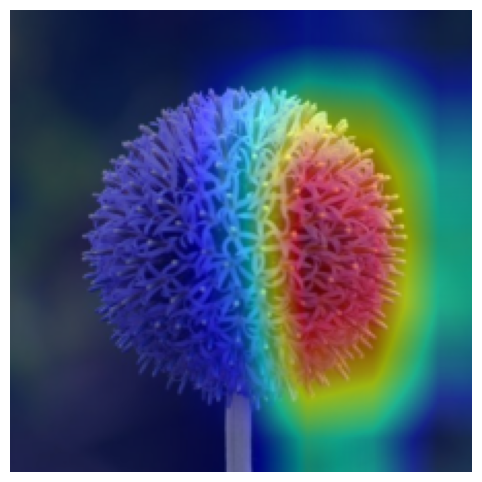

In [48]:
plt.figure(figsize=(6, 6))

plt.imshow(overlay)

plt.axis("off")

plt.show()

In [49]:
def generate_gradcam(
    example,
    model,
    gradcam,
    device,
    image_size=224
):

    image = example["image"].unsqueeze(0).to(device)

    cam = gradcam.generate(
        image,
        class_idx=example["prediction"]
    )

    heatmap = cv2.resize(
        cam,
        (image_size, image_size)
    )

    heatmap = np.uint8(
        255 * heatmap
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    heatmap = heatmap.astype(
        np.float32
    ) / 255

    original = denormalize(
        example["image"]
    )

    original = original.permute(
        1, 2, 0
    ).numpy()

    overlay = (
        0.5 * original +
        0.5 * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return original, heatmap, overlay

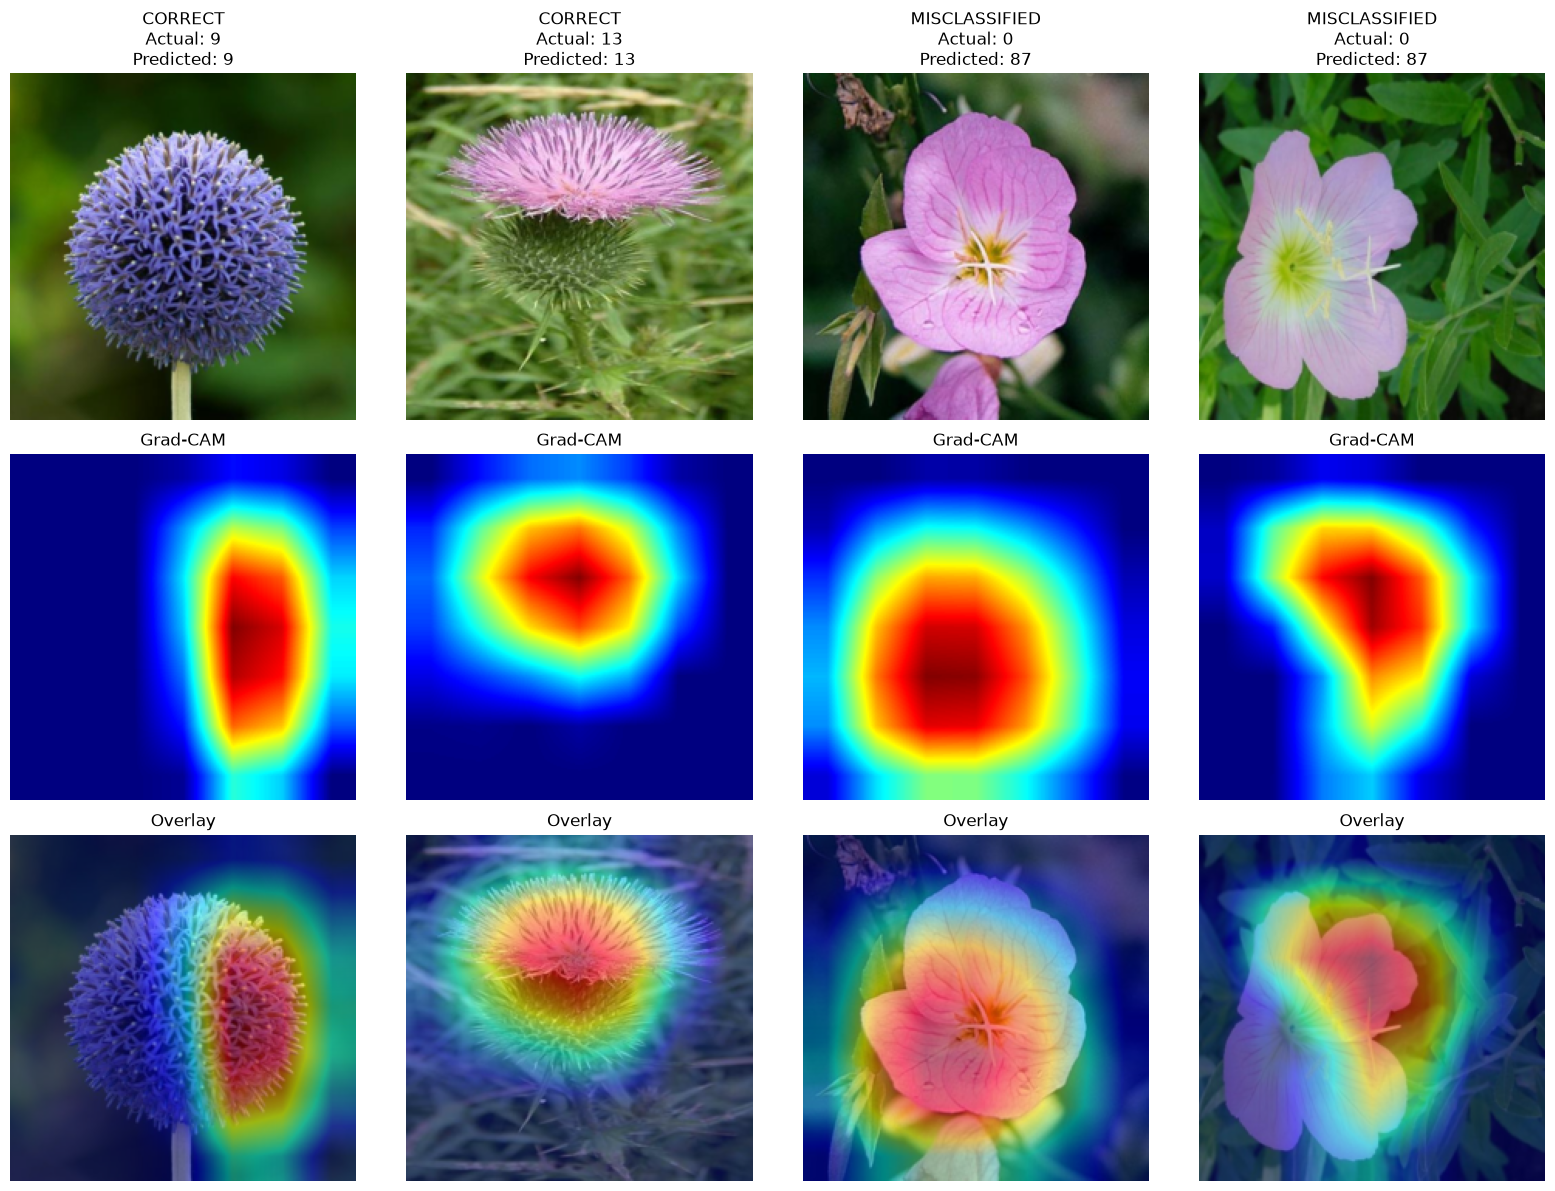

In [50]:
examples = (
    correct_images[:2] +
    incorrect_images[:2]
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

for col, example in enumerate(examples):

    original, heatmap, overlay = generate_gradcam(
        example,
        model,
        gradcam,
        device
    )

    actual = example["label"]
    predicted = example["prediction"]

    # Original
    axes[0, col].imshow(original)

    # Heatmap
    axes[1, col].imshow(heatmap)

    # Overlay
    axes[2, col].imshow(overlay)

    if actual == predicted:
        result = "CORRECT"
    else:
        result = "MISCLASSIFIED"

    axes[0, col].set_title(
        f"{result}\n"
        f"Actual: {actual}\n"
        f"Predicted: {predicted}"
    )

    axes[1, col].set_title(
        "Grad-CAM"
    )

    axes[2, col].set_title(
        "Overlay"
    )

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()